In [1]:
from datascience import * 
import matplotlib
import numpy as np
import matplotlib.pyplot as plots
path_data = '../../data/data8/'
matplotlib.use('Agg')
%matplotlib inline
plots.style.use('fivethirtyeight')


In [2]:
# Data on heights of parents and their adult children
family_heights = Table.read_table(path_data + 'family_heights.csv').drop(3)
family_heights

family,father,mother,children,childNum,sex,childHeight
1,78.5,67,4,1,male,73.2
1,78.5,67,4,2,female,69.2
1,78.5,67,4,3,female,69
1,78.5,67,4,4,female,69
2,75.5,66.5,4,1,male,73.5
2,75.5,66.5,4,2,male,72.5
2,75.5,66.5,4,3,female,65.5
2,75.5,66.5,4,4,female,65.5
3,75,64,2,1,male,71
3,75,64,2,2,female,68


In [3]:
parent_averages = (family_heights.column('father') + family_heights.column('mother'))/2
heights = Table().with_columns(
    'Parent Average', parent_averages,
    'Child', family_heights.column('childHeight')
)
heights

Parent Average,Child
72.75,73.2
72.75,69.2
72.75,69
72.75,69
71,73.5
71,72.5
71,65.5
71,65.5
69.5,71
69.5,68


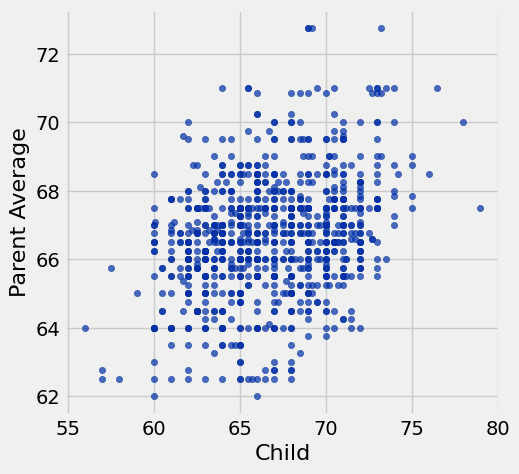

In [5]:
heights.scatter('Child')

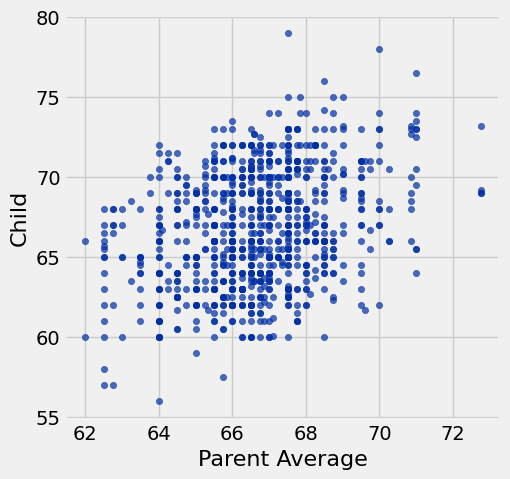

In [6]:
heights.scatter('Parent Average')

In [7]:
close_to_68 = heights.where('Parent Average', are.between(67.5, 68.5))
close_to_68

Parent Average,Child
68,74
68,70
68,68
68,67
68,67
68,66
68,63.5
68,63
67.5,65
68.1,62.7


In [1]:
ss = np.average(close_to_68.column('Child'));
np.round(ss,2)

NameError: name 'np' is not defined

For some strange reason, `np.round` does not round the decimals.

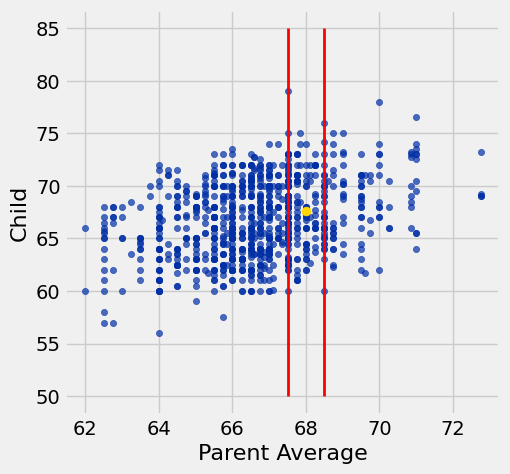

In [26]:
heights.scatter('Parent Average')
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2)
plots.scatter(68, ss, color='gold', s=40);

In [24]:
def predict_child(p_avg):
    """Predict the height of a child whose parents have a parent average height of p_avg.
    
    The prediction is the average height of the children whose parent average height is
    in the range p_avg plus or minus 0.5.
    """
    
    close_points = heights.where('Parent Average', are.between(p_avg-0.5, p_avg + 0.5))
    return np.average(close_points.column('Child'))    

In [27]:
predict_child(68)

67.620000000000005

In [28]:
predict_child(65)

65.838297872340434

To test how good our predictions are, we should apply them to the column of Parent Average heights.

In [29]:
# Apply predict_child to all the midparent heights

heights_with_predictions = heights.with_column(
    'Prediction', heights.apply(predict_child, 'Parent Average')
)
heights_with_predictions

Parent Average,Child,Prediction
72.75,73.2,70.1
72.75,69.2,70.1
72.75,69,70.1
72.75,69,70.1
71,73.5,70.4158
71,72.5,70.4158
71,65.5,70.4158
71,65.5,70.4158
69.5,71,68.5025
69.5,68,68.5025


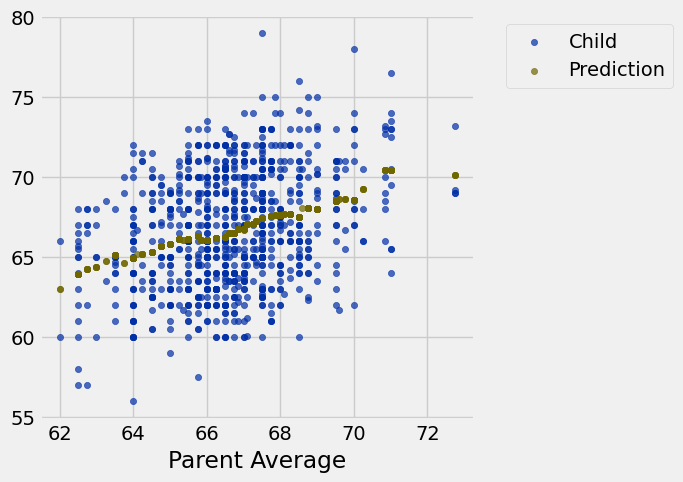

In [31]:
heights_with_predictions.scatter("Parent Average")

The graph of non-blue dots is called a graph of averages, because each non-blue dot is the center of a vertical strip like the one we drew earlier. 

Each one provides a prediction of a child’s height given the parent average height. 

For example, the scatter shows that for a parent average height of 65 inches, the predicted height of the child would be just above 65 inches, and indeed `predict_child(65)` evaluates to about 65.84.

Notice that the graph of averages roughly follows a straight line. This straight line is now called the _regression line_ and is one of the most common methods of making predictions. 

The calculation that we have just done is very similar to the calculation that led to the development of the regression method, using the same data.